# 01 — Data Exploration

This notebook verifies the synthetic data generation pipeline and the graph extraction tools.
Run this before starting any model experiments to confirm the ground-truth semantic structure
is being extracted correctly.

In [1]:
import sys
sys.path.insert(0, '..')

from src.data.generator import SyntheticCodeGenerator, SyntheticSpec
from src.graphs.ast_extractor import ASTExtractor
from src.graphs.dfg_extractor import DefUseExtractor
from src.graphs.cfg_extractor import CFGExtractor
from src.graphs.pdg_extractor import PDGExtractor

import networkx as nx
import matplotlib.pyplot as plt

## 1. Generate a synthetic example

In [2]:
gen = SyntheticCodeGenerator(seed=42)
ex = gen.generate_binding(SyntheticSpec(n_vars=3, chain_length=3, has_dead_def=True))
print(ex.source)

def func():
    a = 81
    b = 14
    c = 3
    b = b + a
    c = c + b
    a = a + c
    d = 999
    return c


## 2. AST extraction

In [3]:
ast_extractor = ASTExtractor()
nodes = ast_extractor.extract(ex.source)
print(f"Extracted {len(nodes)} AST nodes")
for n in nodes[:10]:
    print(f"  {n}")

Extracted 30 AST nodes
  ASTNode(FunctionDef name='func' [0:110])
  ASTNode(Assign [16:22])
  ASTNode(Name name='a' [16:17])
  ASTNode(Constant [20:22])
  ASTNode(Assign [27:33])
  ASTNode(Name name='b' [27:28])
  ASTNode(Constant [31:33])
  ASTNode(Assign [38:43])
  ASTNode(Name name='c' [38:39])
  ASTNode(Constant [42:43])


## 3. Def-use graph extraction

In [4]:
dfg_extractor = DefUseExtractor()
dfg = dfg_extractor.extract(ex.source)
print(f"Extracted {len(dfg)} def-use edges")
for edge in dfg.edges:
    print(f"  {edge}")

Extracted 7 def-use edges
  DefUseEdge('b' def@5 → use@5)
  DefUseEdge('a' def@2 → use@5)
  DefUseEdge('c' def@6 → use@6)
  DefUseEdge('b' def@5 → use@6)
  DefUseEdge('a' def@7 → use@7)
  DefUseEdge('c' def@6 → use@7)
  DefUseEdge('c' def@6 → use@9)


## 4. Visualize the def-use graph

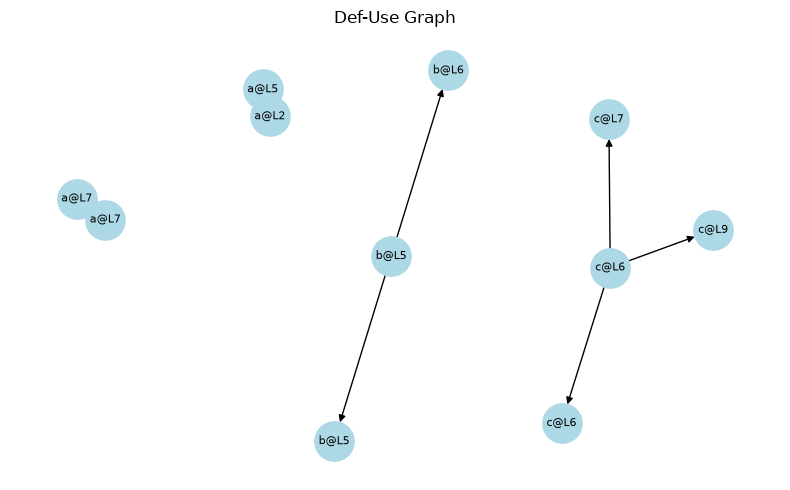

In [5]:
fig, ax = plt.subplots(figsize=(8, 5))
pos = nx.spring_layout(dfg.graph, seed=0)
labels = {
    n: f"{n[0]}@L{n[1]}"
    for n in dfg.graph.nodes
}
nx.draw(dfg.graph, pos, labels=labels, ax=ax,
        node_color='lightblue', node_size=800,
        arrows=True, font_size=8)
ax.set_title('Def-Use Graph')
plt.tight_layout()
plt.show()

## 5. Taint example — vulnerable vs safe

In [6]:
vuln = gen.generate_taint(sanitized=False, chain_length=2)
safe = gen.generate_taint(sanitized=True, chain_length=2)

print("=== VULNERABLE ===")
print(vuln.source)
print("\n=== SAFE ===")
print(safe.source)

=== VULNERABLE ===
def func():
    x = os.environ.get('VAR')
    v0 = x
    v1 = v0
    exec(v1)

=== SAFE ===
def func():
    x = input()
    v0 = x
    v1 = v0
    safe = shlex.quote(v1)
    eval(safe)


## 6. Shadow example — adversarial for binding probes

In [7]:
shadow = gen.generate_shadow()
print(shadow.source)
print()

dfg_shadow = dfg_extractor.extract(shadow.source)
print(f"Def-use edges for shadow example ({len(dfg_shadow)} edges):")
for edge in dfg_shadow.edges:
    print(f"  {edge.definition.name!r} def@L{edge.definition.line} → use@L{edge.use.line}")

def func(x):
    result = x * 2
    if result > 10:
        x = result - 5   # shadows parameter x
        result = x + 1   # this 'x' refers to the reassigned x
    return result


Def-use edges for shadow example (5 edges):
  'x' def@L1 → use@L2
  'result' def@L2 → use@L3
  'result' def@L2 → use@L4
  'x' def@L4 → use@L5
  'result' def@L5 → use@L6


## 7. Batch statistics

Check the distribution of edge counts, chain lengths, etc. across a generated batch.

Batch size: 170
Def-use edges per example: mean=5.2, min=2, max=9


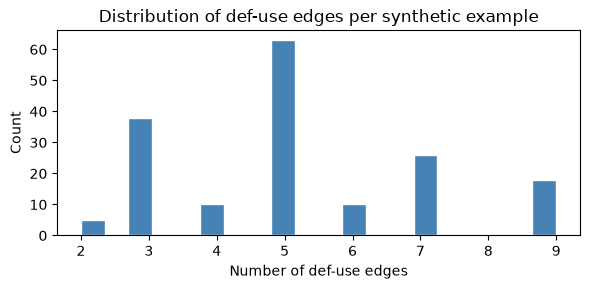

In [8]:
batch = gen.generate_batch(n_binding=100, n_taint=50, n_shadow=20)

edge_counts = []
for ex in batch:
    dfg = dfg_extractor.extract(ex.source)
    edge_counts.append(len(dfg))

import numpy as np
print(f"Batch size: {len(batch)}")
print(f"Def-use edges per example: mean={np.mean(edge_counts):.1f}, "
      f"min={min(edge_counts)}, max={max(edge_counts)}")

fig, ax = plt.subplots(figsize=(6, 3))
ax.hist(edge_counts, bins=20, color='steelblue', edgecolor='white')
ax.set_xlabel('Number of def-use edges')
ax.set_ylabel('Count')
ax.set_title('Distribution of def-use edges per synthetic example')
plt.tight_layout()
plt.show()